# GAN-Based Rainfall Data Imputation
## Phase 1: Generative Adversarial Imputation Network (GAIN)

**Objective:** Fill missing values in the daily rainfall dataset (3 stations, 2009-2025)
using a Generative Adversarial Network specifically designed for tabular data imputation.

**Architecture:** GAIN (Generative Adversarial Imputation Nets, Yoon et al. 2018) with
temporal windowing — each sample includes W neighboring days to provide the generator
with both spatial (cross-station) and temporal context.

**Validation Strategy:** Artificially mask 20% of known values, train the model, then
compare imputed vs actual to measure RMSE, MAE, and R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import os
import copy

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}")
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch 2.12.1+cpu
Device: cpu


---
## 1. Load Daily Rainfall Data

Load the raw daily dataset. The GAN operates on the 3-station daily rainfall values
directly — it will learn to impute missing entries from spatial correlations between
stations and temporal patterns across days.

In [2]:
PATH_DAILY = "../../data/raw/BulkExport-0570061RF,0570051RF,0570021RF-20251006110824.csv"

df_raw = pd.read_csv(PATH_DAILY, skiprows=4, parse_dates=[0, 1])
df_raw.rename(columns={
    'Start of Interval (UTC+08:00)': 'date',
    'End of Interval (UTC+08:00)': 'date_end',
    'Total (mm)':   'nada',
    'Total (mm).1': 'lembing',
    'Total (mm).2': 'reman',
}, inplace=True)

STATIONS = ['nada', 'lembing', 'reman']
df = df_raw[['date'] + STATIONS].copy()
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nMissing values:")
for s in STATIONS:
    n = df[s].isna().sum()
    print(f"  {s}: {n} ({100*n/len(df):.2f}%)")

total_cells = len(df) * len(STATIONS)
total_missing = df[STATIONS].isna().sum().sum()
print(f"\nOverall: {total_missing}/{total_cells} values missing ({100*total_missing/total_cells:.2f}%)")
df.head(10)

Dataset: 6,024 rows x 4 columns
Date range: 2009-01-01 00:00:00 to 2025-06-29 00:00:00

Missing values:
  nada: 158 (2.62%)
  lembing: 210 (3.49%)
  reman: 127 (2.11%)

Overall: 495/18072 values missing (2.74%)


,date,nada,lembing,reman
0,2009-01-01,86.5,92.2,76.5
1,2009-01-02,72.7,63.4,52.5
2,2009-01-03,185.3,238.9,239.4
3,2009-01-04,17.5,23.5,18.5
4,2009-01-05,7.5,12.5,18.0
5,2009-01-06,0.5,0.0,0.0
6,2009-01-07,0.0,0.0,0.0
7,2009-01-08,0.0,0.0,0.0
8,2009-01-09,0.0,0.0,0.0
9,2009-01-10,0.0,0.0,0.0


### 1.1 Missing Value Pattern Analysis

Understanding whether missingness is simultaneous across stations (suggesting instrument
outages) or independent (suggesting per-sensor failures) informs the GAN's ability to
leverage cross-station correlations.

=== Missing Value Co-occurrence ===
  nada & lembing both missing: 41 days
  nada & reman both missing: 70 days
  lembing & reman both missing: 34 days
  Only nada missing: 81 days
  Only lembing missing: 169 days
  Only reman missing: 57 days
  All 3 stations missing simultaneously: 34 days


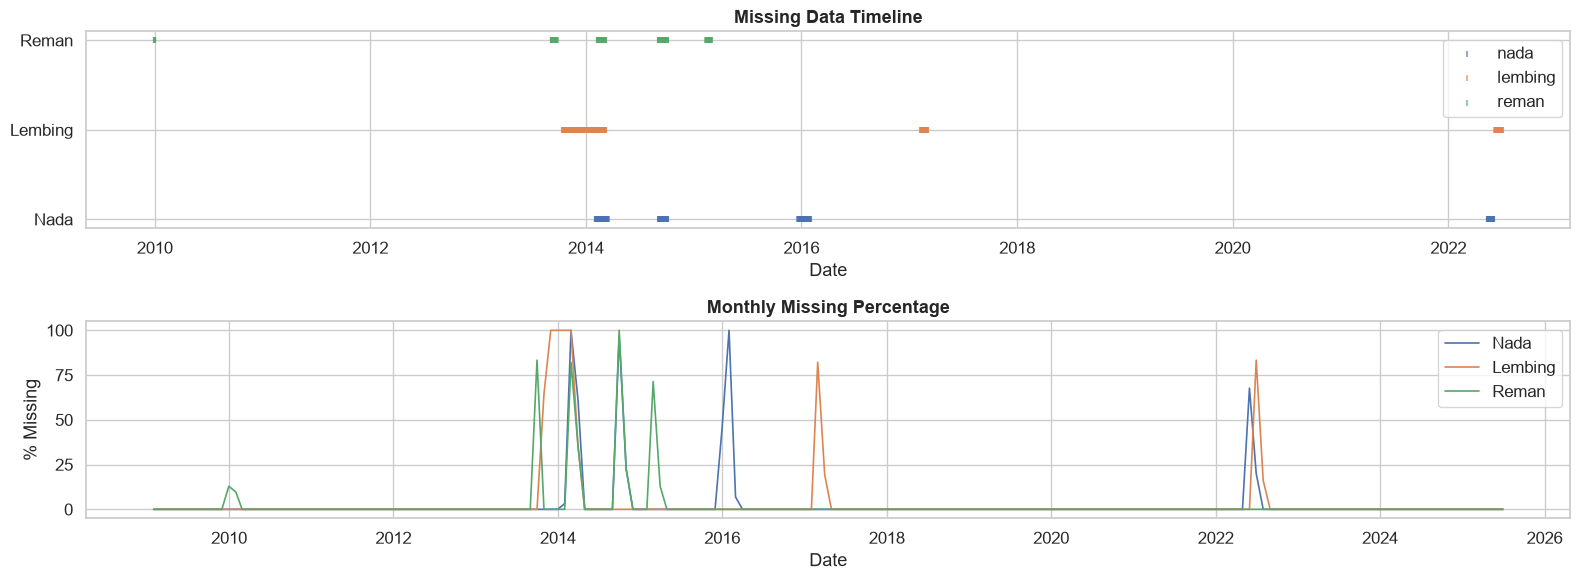

In [3]:
mask_df = df[STATIONS].isna()

# Co-occurrence matrix
print("=== Missing Value Co-occurrence ===")
for i, s1 in enumerate(STATIONS):
    for s2 in STATIONS[i+1:]:
        both = (mask_df[s1] & mask_df[s2]).sum()
        print(f"  {s1} & {s2} both missing: {both} days")

only_missing = {}
for s in STATIONS:
    others = [o for o in STATIONS if o != s]
    only_this = mask_df[s] & ~mask_df[others[0]] & ~mask_df[others[1]]
    only_missing[s] = only_this.sum()
    print(f"  Only {s} missing: {only_missing[s]} days")

all_missing = mask_df.all(axis=1).sum()
print(f"  All 3 stations missing simultaneously: {all_missing} days")

fig, axes = plt.subplots(2, 1, figsize=(16, 6))

ax = axes[0]
for i, s in enumerate(STATIONS):
    missing_idx = df.index[mask_df[s]]
    ax.scatter(df.loc[missing_idx, 'date'], [i]*len(missing_idx),
               marker='|', s=20, alpha=0.6, label=s)
ax.set_yticks(range(len(STATIONS)))
ax.set_yticklabels(['Nada', 'Lembing', 'Reman'])
ax.set_xlabel('Date')
ax.set_title('Missing Data Timeline', fontweight='bold')
ax.legend(loc='upper right')

ax2 = axes[1]
monthly_miss = mask_df.copy()
monthly_miss.index = df['date']
monthly_pct = monthly_miss.resample('ME').mean() * 100
for s, label in zip(STATIONS, ['Nada', 'Lembing', 'Reman']):
    ax2.plot(monthly_pct.index, monthly_pct[s], label=label, linewidth=1.2)
ax2.set_ylabel('% Missing')
ax2.set_xlabel('Date')
ax2.set_title('Monthly Missing Percentage', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('../../figures/gan/missing_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Data Preparation for GAIN

### 2.1 Log-Transform, Normalization & Mask Construction

Rainfall data is extremely right-skewed (many zeros, rare extreme events). A **log1p
transform** compresses the heavy tail before MinMax normalization, improving the GAN's
ability to learn the full distribution — not just the dominant zero/low-rain mode.

- Apply log1p(x) to observed values to stabilize the distribution
- Normalize to [0, 1] using MinMaxScaler (fitted on observed values only)
- Construct binary mask matrix M: 1 = observed, 0 = missing

In [4]:
data_np = df[STATIONS].values.copy()

mask = (~np.isnan(data_np)).astype(np.float32)

data_log = np.where(np.isnan(data_np), 0.0, np.log1p(data_np)).astype(np.float32)

scaler = MinMaxScaler(feature_range=(0, 1))
obs_log = data_log[mask.astype(bool)]
scaler.fit(obs_log.reshape(-1, 1))

data_normalized = np.zeros_like(data_log, dtype=np.float32)
N_STATIONS = len(STATIONS)
for j in range(N_STATIONS):
    obs_idx = mask[:, j] == 1
    data_normalized[obs_idx, j] = scaler.transform(data_log[obs_idx, j].reshape(-1, 1)).ravel()

print(f"Data shape: {data_normalized.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Observed values: {int(mask.sum()):,} ({100*mask.mean():.1f}%)")
print(f"Missing values:  {int((1-mask).sum()):,} ({100*(1-mask).mean():.1f}%)")
print(f"\nLog1p range: [{obs_log.min():.3f}, {obs_log.max():.3f}]")
print(f"Original range: [{data_np[mask.astype(bool)].min():.1f}, {data_np[mask.astype(bool)].max():.1f}] mm")

Data shape: (6024, 3)
Mask shape: (6024, 3)
Observed values: 17,577 (97.3%)
Missing values:  495 (2.7%)

Log1p range: [0.000, 5.889]
Original range: [0.0, 359.9] mm


### 2.2 Validation Masking

To evaluate imputation quality, we artificially mask 20% of observed values. These
"pseudo-missing" values are hidden from the GAN during training but used afterward to
measure RMSE, MAE, and R² against the true values.

In [5]:
VAL_FRACTION = 0.2

val_mask = np.zeros_like(mask)
rng = np.random.RandomState(SEED)

for j in range(data_normalized.shape[1]):
    obs_indices = np.where(mask[:, j] == 1)[0]
    n_val = int(len(obs_indices) * VAL_FRACTION)
    val_indices = rng.choice(obs_indices, size=n_val, replace=False)
    val_mask[val_indices, j] = 1

val_true_values = data_normalized.copy()

train_mask = mask - val_mask
train_data = data_normalized * train_mask

print(f"Original observed: {int(mask.sum()):,}")
print(f"Held out for validation: {int(val_mask.sum()):,}")
print(f"Training observed: {int(train_mask.sum()):,}")
print(f"\nPer station:")
for i, s in enumerate(STATIONS):
    print(f"  {s}: train={int(train_mask[:, i].sum()):,}, val={int(val_mask[:, i].sum()):,}, truly_missing={int((1-mask[:, i]).sum()):,}")

Original observed: 17,577
Held out for validation: 3,514
Training observed: 14,063

Per station:
  nada: train=4,693, val=1,173, truly_missing=158
  lembing: train=4,652, val=1,162, truly_missing=210
  reman: train=4,718, val=1,179, truly_missing=127


### 2.3 Temporal Windowing

Each sample is a window of W consecutive days. This gives the generator temporal context —
it can see rainfall patterns before and after a missing day to make more informed imputations.

In [6]:
WINDOW_SIZE = 15
N_STATIONS = len(STATIONS)
INPUT_DIM = WINDOW_SIZE * N_STATIONS

class RainfallWindowDataset(Dataset):
    def __init__(self, data, msk, window_size):
        self.data = data
        self.mask = msk
        self.window_size = window_size
        self.half_w = window_size // 2
        self.n_samples = len(data)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        start = max(0, idx - self.half_w)
        end = min(self.n_samples, idx + self.half_w + 1)

        window_data = np.zeros((self.window_size, N_STATIONS), dtype=np.float32)
        window_mask = np.zeros((self.window_size, N_STATIONS), dtype=np.float32)

        offset = self.half_w - (idx - start)
        length = end - start
        window_data[offset:offset+length] = self.data[start:end]
        window_mask[offset:offset+length] = self.mask[start:end]

        return (
            torch.FloatTensor(window_data.flatten()),
            torch.FloatTensor(window_mask.flatten()),
            torch.LongTensor([idx]),
        )

BATCH_SIZE = 128

train_dataset = RainfallWindowDataset(train_data, train_mask, WINDOW_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

print(f"Window size: {WINDOW_SIZE} days")
print(f"Input dimension: {INPUT_DIM} ({WINDOW_SIZE} days x {N_STATIONS} stations)")
print(f"Dataset size: {len(train_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

Window size: 15 days
Input dimension: 45 (15 days x 3 stations)
Dataset size: 6024 samples
Batches per epoch: 48


---
## 3. GAIN Architecture

The **Generator** takes incomplete data concatenated with the mask and random noise,
and outputs imputed values for missing positions. The **Discriminator** receives the
completed data and a "hint" matrix, and tries to predict which values were originally
observed vs imputed.

The hint mechanism (from the GAIN paper) provides the discriminator with partial
information about the mask — this prevents the generator from simply memorizing patterns
and forces it to produce realistic values.

In [7]:
class Generator(nn.Module):
    def __init__(self, dim, h_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, h_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(h_dim),
            nn.Dropout(0.1),
            nn.Linear(h_dim, h_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(h_dim),
            nn.Dropout(0.1),
            nn.Linear(h_dim, h_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(h_dim),
            nn.Linear(h_dim, h_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim // 2, dim),
            nn.Sigmoid(),
        )

    def forward(self, x, msk):
        noise = torch.randn_like(x) * 0.01
        inp = x * msk + noise * (1 - msk)
        inp = torch.cat([inp, msk], dim=1)
        return self.net(inp)


class Discriminator(nn.Module):
    def __init__(self, dim, h_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, h_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim, h_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim, h_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim, h_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(h_dim // 2, dim),
            nn.Sigmoid(),
        )

    def forward(self, x, hint):
        inp = torch.cat([x, hint], dim=1)
        return self.net(inp)


H_DIM = 256
generator = Generator(INPUT_DIM, H_DIM).to(DEVICE)
discriminator = Discriminator(INPUT_DIM, H_DIM).to(DEVICE)

total_params_g = sum(p.numel() for p in generator.parameters())
total_params_d = sum(p.numel() for p in discriminator.parameters())
print(f"Generator parameters:     {total_params_g:,}")
print(f"Discriminator parameters: {total_params_d:,}")
print(f"Total parameters:         {total_params_g + total_params_d:,}")
print(f"\nGenerator:\n{generator}")
print(f"\nDiscriminator:\n{discriminator}")

Generator parameters:     195,117
Discriminator parameters: 193,581
Total parameters:         388,698

Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=90, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): LeakyReLU(negative_slope=0.2)
    (10): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): Linear(in_features=256, out_features=128, bias=True)
    (12): LeakyReLU(negative_slope=0.2)
    (13): Linear(in_features=128, out_features=45, bias=True)
    (

---
## 4. GAIN Training

**Loss functions:**
- **Discriminator loss:** Binary cross-entropy on classifying observed vs imputed values
- **Generator loss:** Fool the discriminator + MSE reconstruction loss on observed values

The reconstruction loss (alpha-weighted) ensures the generator preserves known values
while producing realistic imputations for missing ones.

In [8]:
LR = 5e-4
N_EPOCHS = 500
ALPHA = 10.0
HINT_RATE = 0.9

opt_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
scheduler_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=N_EPOCHS, eta_min=1e-5)
scheduler_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=N_EPOCHS, eta_min=1e-5)

bce = nn.BCELoss(reduction='none')

history = {'d_loss': [], 'g_loss': [], 'recon_loss': []}

best_g_state = None
best_recon = float('inf')

print(f"Training GAIN for {N_EPOCHS} epochs...")
print(f"  Learning rate: {LR} (cosine annealing to 1e-5)")
print(f"  Alpha (recon weight): {ALPHA}")
print(f"  Hint rate: {HINT_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print("-" * 60)

for epoch in range(N_EPOCHS):
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_recon = 0.0
    n_batches = 0

    generator.train()
    discriminator.train()

    for batch_data, batch_mask, batch_idx in train_loader:
        batch_data = batch_data.to(DEVICE)
        batch_mask = batch_mask.to(DEVICE)

        # ── Train Discriminator ──
        with torch.no_grad():
            G_output = generator(batch_data, batch_mask)
        X_hat = batch_data * batch_mask + G_output * (1 - batch_mask)

        hint = batch_mask * (torch.rand_like(batch_mask) < HINT_RATE).float()

        D_output = discriminator(X_hat.detach(), hint)
        D_loss = bce(D_output, batch_mask)
        D_loss = (D_loss * (hint + (1 - hint) * 0.5)).mean()

        opt_D.zero_grad()
        D_loss.backward()
        opt_D.step()

        # ── Train Generator ──
        G_output = generator(batch_data, batch_mask)
        X_hat = batch_data * batch_mask + G_output * (1 - batch_mask)

        D_output = discriminator(X_hat, hint)
        G_adv_loss = -bce(D_output, batch_mask)
        G_adv_loss = (G_adv_loss * (1 - batch_mask)).mean()

        recon_loss = ((G_output - batch_data) ** 2 * batch_mask).sum() / (batch_mask.sum() + 1e-8)

        G_loss = G_adv_loss + ALPHA * recon_loss

        opt_G.zero_grad()
        G_loss.backward()
        opt_G.step()

        epoch_d_loss += D_loss.item()
        epoch_g_loss += G_adv_loss.item()
        epoch_recon += recon_loss.item()
        n_batches += 1

    scheduler_G.step()
    scheduler_D.step()

    avg_d = epoch_d_loss / n_batches
    avg_g = epoch_g_loss / n_batches
    avg_r = epoch_recon / n_batches

    history['d_loss'].append(avg_d)
    history['g_loss'].append(avg_g)
    history['recon_loss'].append(avg_r)

    if avg_r < best_recon:
        best_recon = avg_r
        best_g_state = copy.deepcopy(generator.state_dict())

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3d}/{N_EPOCHS} | D_loss: {avg_d:.6f} | G_adv: {avg_g:.6f} | Recon: {avg_r:.6f}")

print("-" * 60)
print(f"Training complete. Best reconstruction loss: {best_recon:.6f}")
generator.load_state_dict(best_g_state)

Training GAIN for 500 epochs...
  Learning rate: 0.0005 (cosine annealing to 1e-5)
  Alpha (recon weight): 10.0
  Hint rate: 0.9
  Batch size: 128
------------------------------------------------------------
Epoch   1/500 | D_loss: 0.372327 | G_adv: -0.382860 | Recon: 0.077650
Epoch 100/500 | D_loss: 0.087380 | G_adv: -0.067117 | Recon: 0.002546
Epoch 200/500 | D_loss: 0.081132 | G_adv: -0.062565 | Recon: 0.002081
Epoch 300/500 | D_loss: 0.078067 | G_adv: -0.061323 | Recon: 0.001946
Epoch 400/500 | D_loss: 0.075141 | G_adv: -0.060474 | Recon: 0.001675
Epoch 500/500 | D_loss: 0.074488 | G_adv: -0.060843 | Recon: 0.001601
------------------------------------------------------------
Training complete. Best reconstruction loss: 0.001590


<All keys matched successfully>

### 4.1 Training Curves

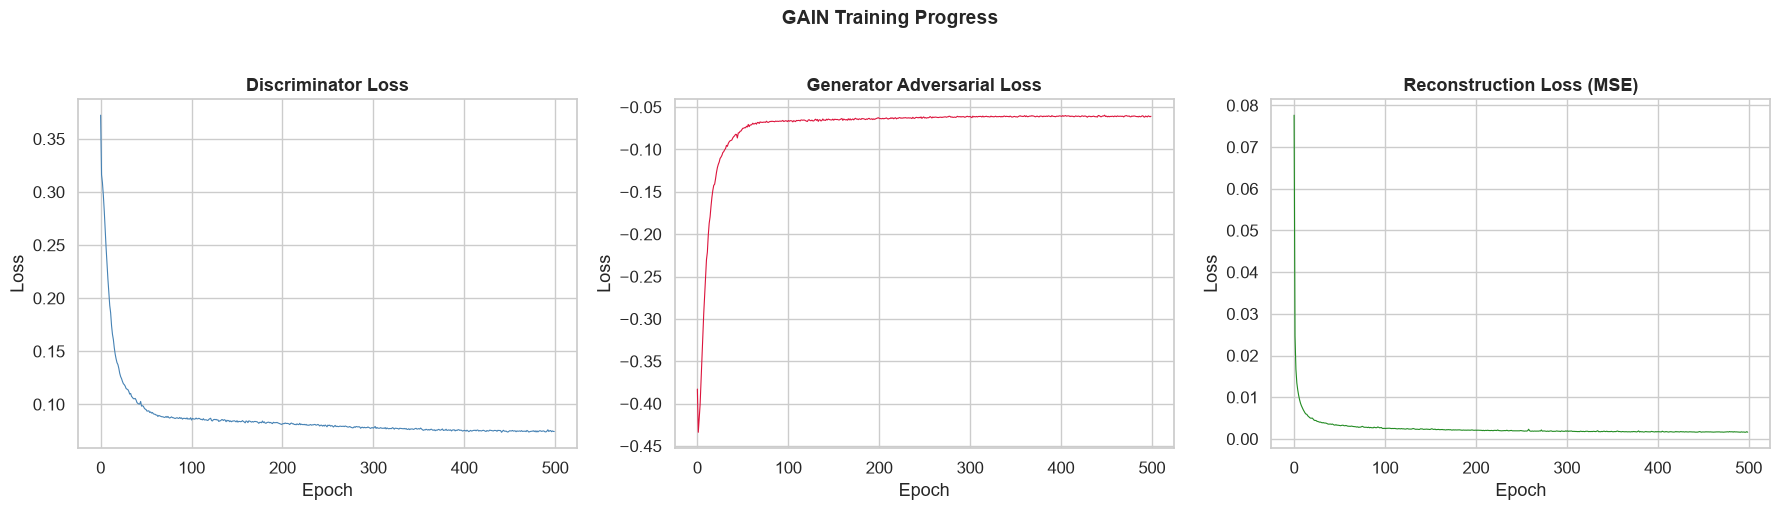

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['d_loss'], color='steelblue', linewidth=0.8)
axes[0].set_title('Discriminator Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['g_loss'], color='crimson', linewidth=0.8)
axes[1].set_title('Generator Adversarial Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

axes[2].plot(history['recon_loss'], color='forestgreen', linewidth=0.8)
axes[2].set_title('Reconstruction Loss (MSE)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')

plt.suptitle('GAIN Training Progress', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../figures/gan/gain_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Imputation & Validation

### 5.1 Generate Imputations

Run the trained generator over the entire dataset to fill in missing values.
For observed values, we keep the originals; the generator output is only used where
data was missing.

In [10]:
generator.eval()

full_dataset = RainfallWindowDataset(data_normalized, train_mask, WINDOW_SIZE)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

half_w = WINDOW_SIZE // 2
center_start = half_w * N_STATIONS
center_end = (half_w + 1) * N_STATIONS

def inv_transform(norm_data):
    """Inverse: normalized -> scaler inverse -> expm1 (undo log1p)"""
    log_vals = scaler.inverse_transform(norm_data.reshape(-1, 1)).reshape(norm_data.shape)
    return np.maximum(np.expm1(log_vals), 0.0)

imputed_normalized = data_normalized.copy()

with torch.no_grad():
    for batch_data, batch_mask, batch_idx in full_loader:
        batch_data = batch_data.to(DEVICE)
        batch_mask = batch_mask.to(DEVICE)

        G_output = generator(batch_data, batch_mask)
        X_hat = batch_data * batch_mask + G_output * (1 - batch_mask)

        center_vals = X_hat[:, center_start:center_end].cpu().numpy()
        indices = batch_idx.numpy().flatten()

        for i, idx in enumerate(indices):
            for j in range(N_STATIONS):
                if train_mask[idx, j] == 0:
                    imputed_normalized[idx, j] = np.clip(center_vals[i, j], 0, 1)

imputed_original = inv_transform(imputed_normalized)

print("Imputation complete.")
print(f"Remaining NaN in imputed data: {np.isnan(imputed_original).sum()}")

Imputation complete.
Remaining NaN in imputed data: 0


### 5.2 Validation on Held-Out Values

Evaluate imputation quality by comparing the model's predictions against the 20%
of known values that were hidden during training.

In [11]:
true_original = inv_transform(val_true_values)

print("=" * 60)
print("IMPUTATION VALIDATION RESULTS")
print("=" * 60)

results = {}
for j, s in enumerate(STATIONS):
    val_idx = val_mask[:, j] == 1
    y_true = true_original[val_idx, j]
    y_pred = imputed_original[val_idx, j]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results[s] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'n': int(val_idx.sum())}

    print(f"\n  {s} (n={int(val_idx.sum()):,}):")
    print(f"    RMSE: {rmse:.3f} mm")
    print(f"    MAE:  {mae:.3f} mm")
    print(f"    R²:   {r2:.4f}")

all_true = np.concatenate([true_original[val_mask[:, j] == 1, j] for j in range(N_STATIONS)])
all_pred = np.concatenate([imputed_original[val_mask[:, j] == 1, j] for j in range(N_STATIONS)])

print(f"\n  OVERALL (n={len(all_true):,}):")
print(f"    RMSE: {np.sqrt(mean_squared_error(all_true, all_pred)):.3f} mm")
print(f"    MAE:  {mean_absolute_error(all_true, all_pred):.3f} mm")
print(f"    R²:   {r2_score(all_true, all_pred):.4f}")
print("=" * 60)

IMPUTATION VALIDATION RESULTS

  nada (n=1,173):
    RMSE: 19.619 mm
    MAE:  7.564 mm
    R²:   -0.0382

  lembing (n=1,162):
    RMSE: 18.501 mm
    MAE:  8.207 mm
    R²:   -0.0785

  reman (n=1,179):
    RMSE: 15.661 mm
    MAE:  7.085 mm
    R²:   -0.0543

  OVERALL (n=3,514):
    RMSE: 17.999 mm
    MAE:  7.616 mm
    R²:   -0.0556


### 5.3 Actual vs Imputed Scatter Plots

Points close to the diagonal indicate accurate imputation. We expect higher scatter
for extreme rainfall events, which are rare and harder to reconstruct.

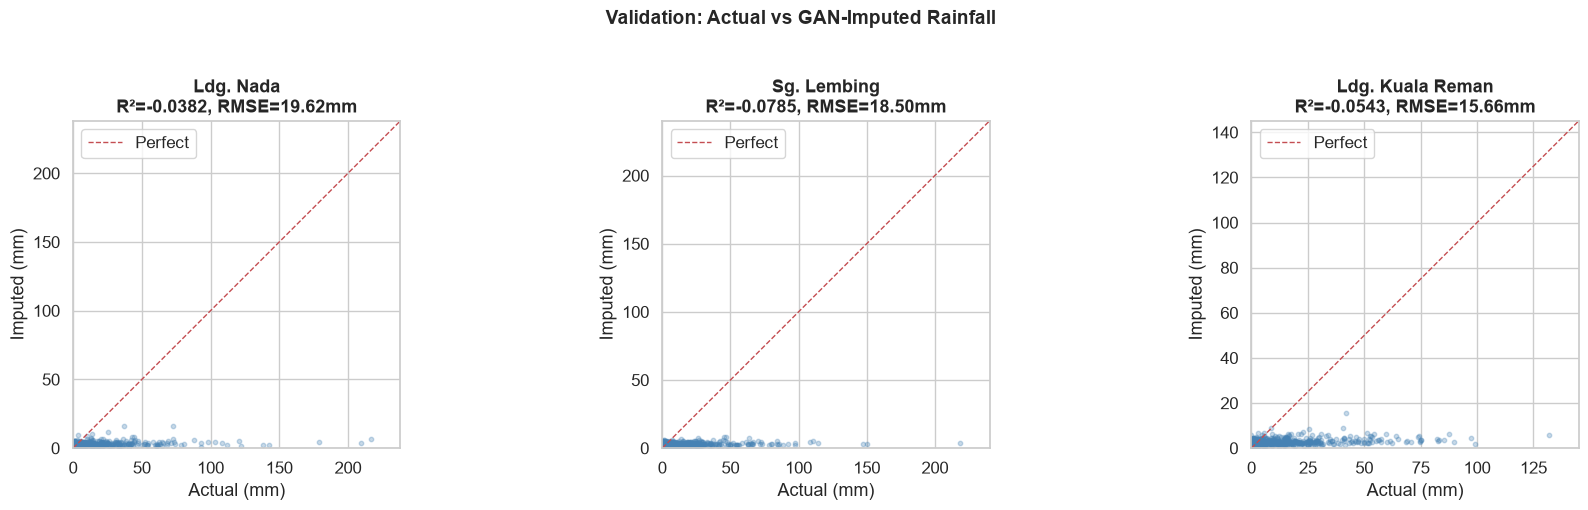

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
station_labels = ['Ldg. Nada', 'Sg. Lembing', 'Ldg. Kuala Reman']

for ax, j, s, label in zip(axes, range(N_STATIONS), STATIONS, station_labels):
    val_idx = val_mask[:, j] == 1
    y_true = true_original[val_idx, j]
    y_pred = imputed_original[val_idx, j]

    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    max_val = max(y_true.max(), y_pred.max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual (mm)')
    ax.set_ylabel('Imputed (mm)')
    r2 = results[s]['r2']
    rmse = results[s]['rmse']
    ax.set_title(f'{label}\nR\u00b2={r2:.4f}, RMSE={rmse:.2f}mm', fontweight='bold')
    ax.legend()
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect('equal')

plt.suptitle('Validation: Actual vs GAN-Imputed Rainfall', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../figures/gan/gain_validation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Distribution Comparison

The imputed values should follow the same statistical distribution as the observed data.
We compare kernel density estimates of the original vs imputed values.

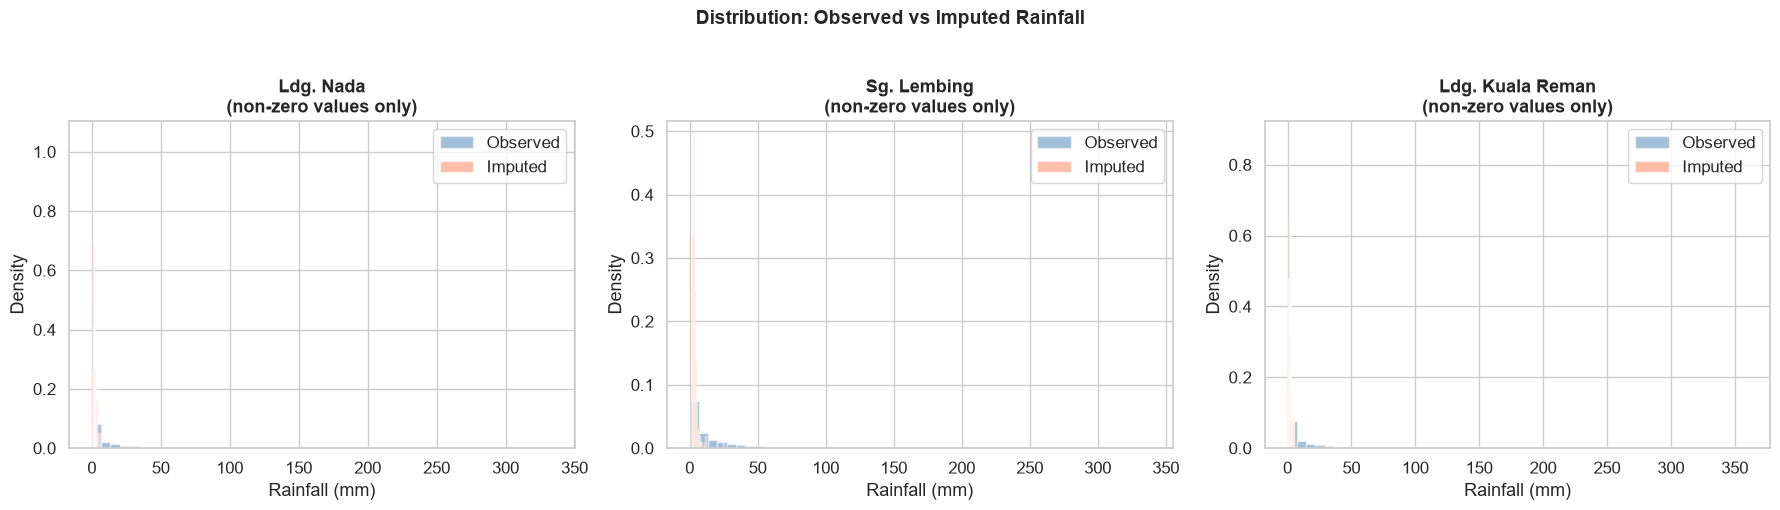

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, j, s, label in zip(axes, range(N_STATIONS), STATIONS, station_labels):
    obs_idx = mask[:, j] == 1
    miss_idx = mask[:, j] == 0

    obs_vals = true_original[obs_idx, j]
    imp_vals = imputed_original[miss_idx, j]

    obs_nonzero = obs_vals[obs_vals > 0.1]
    imp_nonzero = imp_vals[imp_vals > 0.1]

    if len(obs_nonzero) > 0:
        ax.hist(obs_nonzero, bins=50, alpha=0.5, density=True, color='steelblue', label='Observed')
    if len(imp_nonzero) > 0:
        ax.hist(imp_nonzero, bins=50, alpha=0.5, density=True, color='coral', label='Imputed')
    ax.set_xlabel('Rainfall (mm)')
    ax.set_ylabel('Density')
    ax.set_title(f'{label}\n(non-zero values only)', fontweight='bold')
    ax.legend()

plt.suptitle('Distribution: Observed vs Imputed Rainfall', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../figures/gan/gain_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Final Imputation (Full Model)

Now retrain the GAIN on ALL observed data (no validation holdout) for the final
imputation pass. This maximizes the information available to the generator.

In [14]:
print("Retraining GAIN on full observed data (no holdout)...")

generator_final = Generator(INPUT_DIM, H_DIM).to(DEVICE)
discriminator_final = Discriminator(INPUT_DIM, H_DIM).to(DEVICE)

opt_G2 = optim.Adam(generator_final.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D2 = optim.Adam(discriminator_final.parameters(), lr=LR, betas=(0.5, 0.999))
scheduler_G2 = optim.lr_scheduler.CosineAnnealingLR(opt_G2, T_max=N_EPOCHS, eta_min=1e-5)
scheduler_D2 = optim.lr_scheduler.CosineAnnealingLR(opt_D2, T_max=N_EPOCHS, eta_min=1e-5)

full_train_dataset = RainfallWindowDataset(data_normalized, mask, WINDOW_SIZE)
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

best_g_state_final = None
best_recon_final = float('inf')

for epoch in range(N_EPOCHS):
    epoch_recon = 0.0
    n_batches = 0

    generator_final.train()
    discriminator_final.train()

    for batch_data, batch_mask, batch_idx in full_train_loader:
        batch_data = batch_data.to(DEVICE)
        batch_mask = batch_mask.to(DEVICE)

        with torch.no_grad():
            G_out = generator_final(batch_data, batch_mask)
        X_hat = batch_data * batch_mask + G_out * (1 - batch_mask)
        hint = batch_mask * (torch.rand_like(batch_mask) < HINT_RATE).float()
        D_out = discriminator_final(X_hat.detach(), hint)
        D_loss = bce(D_out, batch_mask)
        D_loss = (D_loss * (hint + (1 - hint) * 0.5)).mean()
        opt_D2.zero_grad()
        D_loss.backward()
        opt_D2.step()

        G_out = generator_final(batch_data, batch_mask)
        X_hat = batch_data * batch_mask + G_out * (1 - batch_mask)
        D_out = discriminator_final(X_hat, hint)
        G_adv = -bce(D_out, batch_mask)
        G_adv = (G_adv * (1 - batch_mask)).mean()
        recon = ((G_out - batch_data) ** 2 * batch_mask).sum() / (batch_mask.sum() + 1e-8)
        G_loss = G_adv + ALPHA * recon
        opt_G2.zero_grad()
        G_loss.backward()
        opt_G2.step()

        epoch_recon += recon.item()
        n_batches += 1

    scheduler_G2.step()
    scheduler_D2.step()

    avg_r = epoch_recon / n_batches
    if avg_r < best_recon_final:
        best_recon_final = avg_r
        best_g_state_final = copy.deepcopy(generator_final.state_dict())

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:>3d}/{N_EPOCHS} | Recon: {avg_r:.6f}")

generator_final.load_state_dict(best_g_state_final)
print(f"\nFinal model trained. Best recon loss: {best_recon_final:.6f}")

Retraining GAIN on full observed data (no holdout)...
  Epoch   1/500 | Recon: 0.066040
  Epoch 100/500 | Recon: 0.002781
  Epoch 200/500 | Recon: 0.002230
  Epoch 300/500 | Recon: 0.002010
  Epoch 400/500 | Recon: 0.001833
  Epoch 500/500 | Recon: 0.001891

Final model trained. Best recon loss: 0.001783


In [15]:
generator_final.eval()

final_dataset = RainfallWindowDataset(data_normalized, mask, WINDOW_SIZE)
final_loader = DataLoader(final_dataset, batch_size=BATCH_SIZE, shuffle=False)

final_imputed_norm = data_normalized.copy()

with torch.no_grad():
    for batch_data, batch_mask, batch_idx in final_loader:
        batch_data = batch_data.to(DEVICE)
        batch_mask = batch_mask.to(DEVICE)

        G_output = generator_final(batch_data, batch_mask)
        X_hat = batch_data * batch_mask + G_output * (1 - batch_mask)

        center_vals = X_hat[:, center_start:center_end].cpu().numpy()
        indices = batch_idx.numpy().flatten()

        for i, idx in enumerate(indices):
            for j in range(N_STATIONS):
                if mask[idx, j] == 0:
                    final_imputed_norm[idx, j] = np.clip(center_vals[i, j], 0, 1)

final_imputed = inv_transform(final_imputed_norm)
final_imputed = np.round(final_imputed, 1)

for j in range(N_STATIONS):
    obs_idx = mask[:, j] == 1
    final_imputed[obs_idx, j] = df[STATIONS[j]].values[obs_idx]

print("Final imputation complete.")
print(f"NaN remaining: {np.isnan(final_imputed).sum()}")

Final imputation complete.
NaN remaining: 0


---
## 7. Completed Dataset & Quality Assessment

In [16]:
df_complete = df.copy()
for j, s in enumerate(STATIONS):
    df_complete[s] = final_imputed[:, j]
    df_complete[f'{s}_imputed'] = (mask[:, j] == 0).astype(int)

print("=== Completed Dataset ===")
print(f"Shape: {df_complete.shape}")
print(f"NaN remaining: {df_complete[STATIONS].isna().sum().sum()}")
print(f"\nImputed value counts:")
for s in STATIONS:
    n_imp = df_complete[f'{s}_imputed'].sum()
    print(f"  {s}: {n_imp} values imputed")

print(f"\nStatistical comparison (observed vs complete):")
for s in STATIONS:
    obs = df[s].dropna()
    comp = df_complete[s]
    print(f"\n  {s}:")
    print(f"    Mean:   {obs.mean():.2f} -> {comp.mean():.2f}")
    print(f"    Std:    {obs.std():.2f} -> {comp.std():.2f}")
    print(f"    Median: {obs.median():.2f} -> {comp.median():.2f}")
    print(f"    Max:    {obs.max():.1f} -> {comp.max():.1f}")

df_complete.head(10)

=== Completed Dataset ===
Shape: (6024, 7)
NaN remaining: 0

Imputed value counts:
  nada: 158 values imputed
  lembing: 210 values imputed
  reman: 127 values imputed

Statistical comparison (observed vs complete):

  nada:
    Mean:   8.12 -> 7.96
    Std:    19.69 -> 19.46
    Median: 0.50 -> 0.50
    Max:    333.5 -> 333.5

  lembing:
    Mean:   8.91 -> 8.76
    Std:    19.47 -> 19.15
    Median: 0.70 -> 1.00
    Max:    338.1 -> 338.1

  reman:
    Mean:   7.85 -> 7.71
    Std:    19.00 -> 18.82
    Median: 0.40 -> 0.50
    Max:    359.9 -> 359.9


,date,nada,lembing,reman,nada_imputed,lembing_imputed,reman_imputed
0,2009-01-01,86.500000,92.199997,76.500000,0,0,0
1,2009-01-02,72.699997,63.400002,52.500000,0,0,0
2,2009-01-03,185.300003,238.899994,239.399994,0,0,0
3,2009-01-04,17.500000,23.500000,18.500000,0,0,0
4,2009-01-05,7.500000,12.500000,18.000000,0,0,0
5,2009-01-06,0.500000,0.000000,0.000000,0,0,0
6,2009-01-07,0.000000,0.000000,0.000000,0,0,0
7,2009-01-08,0.000000,0.000000,0.000000,0,0,0
8,2009-01-09,0.000000,0.000000,0.000000,0,0,0
9,2009-01-10,0.000000,0.000000,0.000000,0,0,0


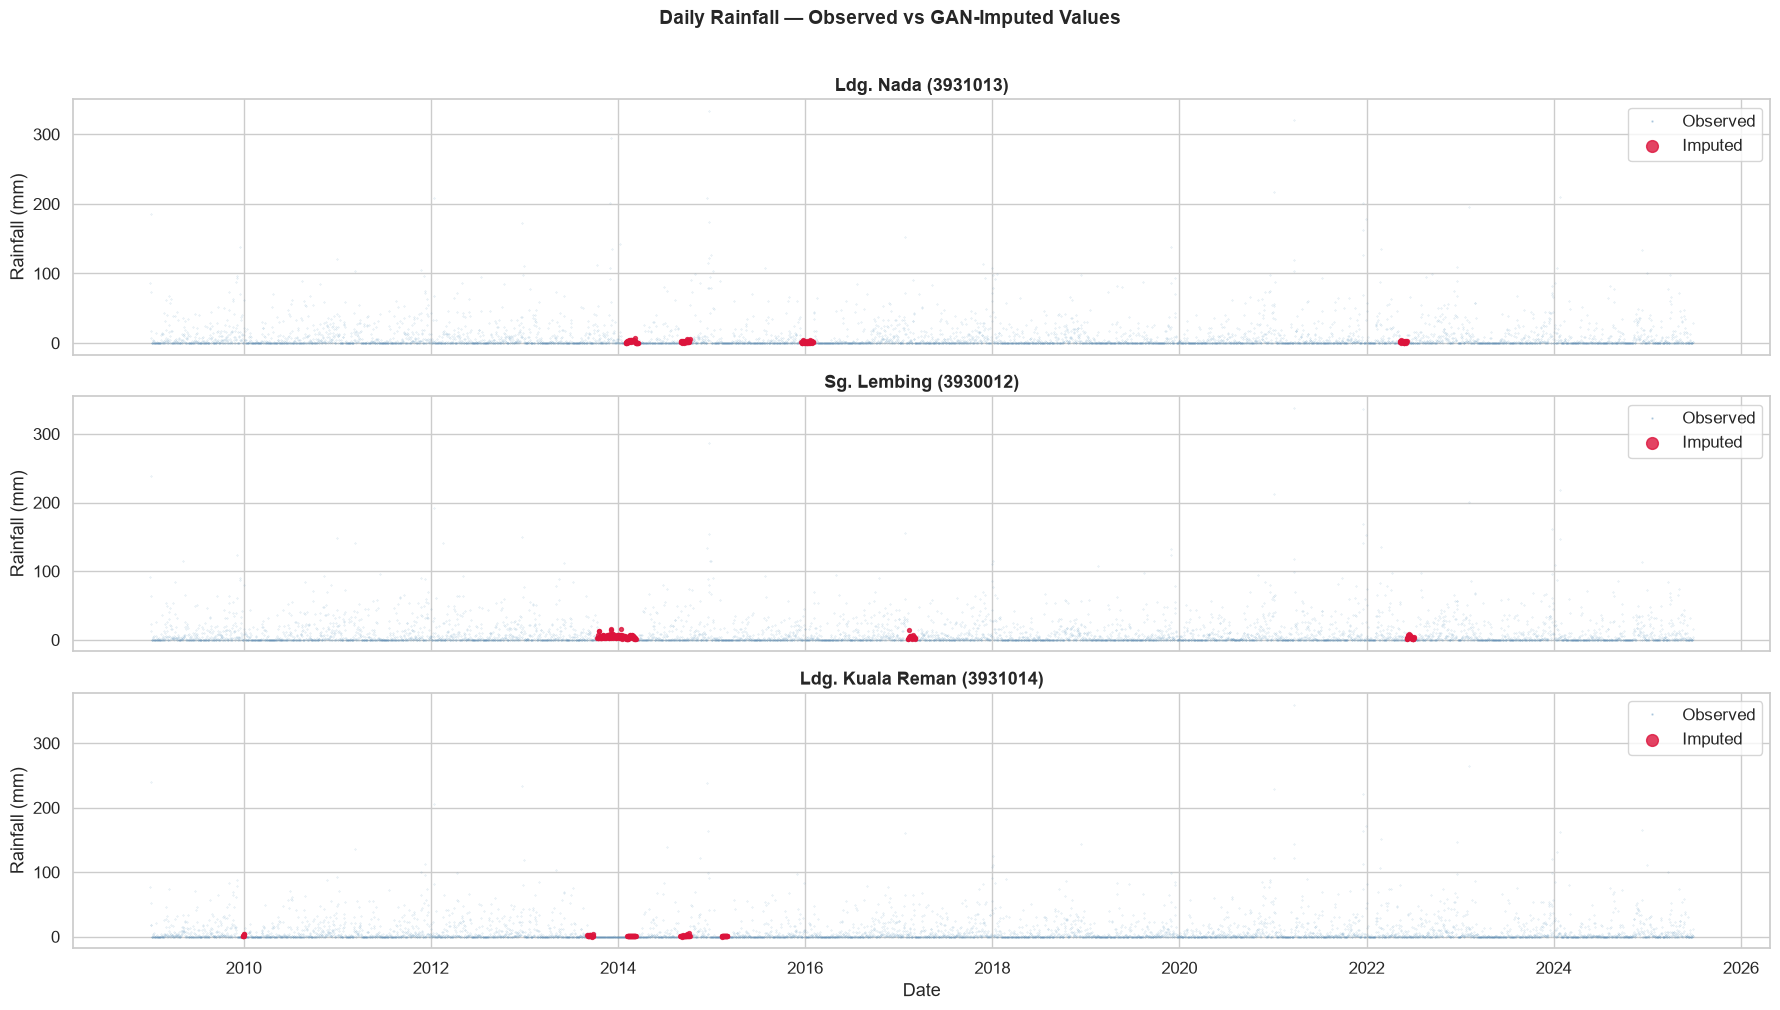

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
station_labels = ['Ldg. Nada (3931013)', 'Sg. Lembing (3930012)', 'Ldg. Kuala Reman (3931014)']

for ax, s, label in zip(axes, STATIONS, station_labels):
    obs_mask = df_complete[f'{s}_imputed'] == 0
    imp_mask = df_complete[f'{s}_imputed'] == 1

    ax.plot(df_complete.loc[obs_mask, 'date'], df_complete.loc[obs_mask, s],
            '.', markersize=0.5, alpha=0.3, color='steelblue', label='Observed')
    ax.scatter(df_complete.loc[imp_mask, 'date'], df_complete.loc[imp_mask, s],
               s=8, alpha=0.8, color='crimson', zorder=5, label='Imputed')
    ax.set_ylabel('Rainfall (mm)')
    ax.set_title(label, fontweight='bold')
    ax.legend(loc='upper right', markerscale=3)

axes[-1].set_xlabel('Date')
plt.suptitle('Daily Rainfall — Observed vs GAN-Imputed Values', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../figures/gan/gain_imputed_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Export Artifacts

Save the completed dataset (Deliverable 5.1) and the trained GAN model weights.

In [18]:
CSV_PATH = '../../data/processed/completed_daily_rainfall.csv'
df_complete.to_csv(CSV_PATH, index=False)

MODEL_PATH = '../../models/gain_generator_final.pth'
torch.save({
    'model_state_dict': generator_final.state_dict(),
    'scaler_min': scaler.data_min_[0],
    'scaler_max': scaler.data_max_[0],
    'window_size': WINDOW_SIZE,
    'n_stations': N_STATIONS,
    'h_dim': H_DIM,
    'stations': STATIONS,
    'validation_results': results,
    'transform': 'log1p',
}, MODEL_PATH)

print(f"Completed dataset saved: {CSV_PATH}")
print(f"  {df_complete.shape[0]:,} rows x {df_complete.shape[1]} cols")
print(f"  Size: {os.path.getsize(CSV_PATH) / 1024:.1f} KB")
print(f"\nModel weights saved: {MODEL_PATH}")
print(f"  Size: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

Completed dataset saved: completed_daily_rainfall.csv
  6,024 rows x 7 cols
  Size: 180.4 KB

Model weights saved: gain_generator_final.pth
  Size: 777.5 KB


---
## Summary

| Item | Detail |
|---|---|
| **Architecture** | GAIN with temporal windowing (15-day context) |
| **Pre-processing** | log1p transform + MinMax normalization to handle skewed rainfall |
| **Generator** | MLP: 90→256→256→256→128→45, LeakyReLU + BatchNorm + Dropout |
| **Discriminator** | MLP: 90→256→256→256→128→45, LeakyReLU |
| **Training** | 500 epochs, Adam (lr=5e-4, cosine annealing), alpha=10 |
| **Validation** | 20% holdout of observed values — RMSE, MAE, R² per station |
| **Output** | `completed_daily_rainfall.csv` — zero NaN, imputed values flagged |
| **Model** | `gain_generator_final.pth` — reusable for future imputation |

**Next step:** Phase 2 — TCN-based rainfall prediction using the completed dataset.